## Part 2. Detecting anomalies and change points in time series of Asian economic data

### Summary

This part applies anomaly and change-point detection methods to Asian economic time series, focusing on Indonesia (1990–2021). It analyzes GDP, green GDP, inflation, FDI, and military spending using Z-Score and Isolation Forest to identify unusual economic events and structural changes.

---

### 2.1 Introduction

#### Methodological overview

##### Detecting anomalies
Anomalies (outliers) are observations that deviate significantly from the expected pattern of a time series.  
They often correspond to **economic shocks, crises, or policy changes**.  

Common approaches include:
- **Statistical methods** (*Z-Score*,...), which identify extreme deviations from the mean.  
- **Machine learning methods** (*Isolation Forest*,...), which model normal behavior and isolate unusual points.

##### Detecting change points
Change points refer to **structural shifts** in the mean or variance of a time series, indicating regime transitions (e.g., before and after an economic crisis).  

Typical algorithms:
- **CUSUM (Cumulative Sum Control Chart)** — detects gradual shifts in the mean.  
- **PELT (Pruned Exact Linear Time)** — efficiently identifies multiple change points across long time spans.

---

#### Economic indicators

- **GDP (Gross Domestic Product):** Measures total economic output.  
- **GGDP (Green GDP):** Adjusts GDP for environmental degradation and resource depletion.  
- **INF (Inflation rate):** Reflects the annual rate of change in consumer prices.  
- **FDI (Foreign Direct Investment):** Represents net inflows of foreign capital.  
- **MIL (Military expenditure):** Government spending on defense and military sectors.

#### Dataset description

##### On the data array “Data02_05_Indonesia_C.csv”

The dataset represents **annual macroeconomic indicators of Indonesia from 1990 to 2021**.  
It is used to analyze time-series patterns, detect anomalies, and identify structural changes in the country’s economic performance.

| **Column** | **Name** | **Description**
|-------------|--------------------|-----------------------------|
| 1 | `year` | Observation year (1990–2021)|
| 2 | `country` | Country name (Indonesia)|
| 3 | `ggdp` | Green Gross Domestic Product|
| 4 | `mil` | Government spending on military|
| 5 | `inf` | Inflation rate|
| 6 | `fdi` | Foreign Direct Investment|
| 7 | `gdp` | Gross Domestic Product|

**Notes:**  
- The data covers **32 yearly observations (1990–2021)**.  
- It allows examining **economic shocks, growth patterns, and investment fluctuations** through multiple indicators.  
- Missing values in some series (e.g., `ggdp`, `mil`) can be interpolated for continuous analysis.



## 2.2 Detecting anomalies

### A. Z-Score Method

#### Overview
The **Z-Score method** is a simple and widely used statistical approach for detecting anomalies (outliers) in time-series data.  
It identifies data points that deviate significantly from the overall mean relative to the series’ standard deviation.

An observation is considered **anomalous** if its absolute Z-Score exceeds a given threshold (commonly `3`).

#### Formula

\[
Z_i = \frac{X_i - \mu}{\sigma}
\]

Where:
- \( X_i \): observed value at time *i*  
- \( \mu \): mean of the time series  
- \( \sigma \): standard deviation of the time series  
- \( Z_i \): standardized score (Z-Score)

#### Detection rule
\[
|Z_i| > \text{threshold} \Rightarrow X_i \text{ is an anomaly}
\]

Typical threshold values:
- **2 ≤ |Z| ≤ 3:** possible mild anomaly  
- **|Z| > 3:** strong anomaly (high deviation)

#### Advantages
- Easy to implement and interpret  
- Works well for **normally distributed** data  
- Useful for identifying **extreme economic events** (e.g., inflation spikes, GDP collapse)

#### Limitations
- Sensitive to non-stationarity (trends or changing variance)  
- May miss anomalies in **non-Gaussian** or skewed distributions  
- Requires mean and standard deviation to be representative of stable behavior

---

In this analysis, we apply the **Z-Score method** with a threshold of **3** to five economic indicators:
1. `ggdp` – Green GDP  
2. `mil` – Military expenditure  
3. `inf` – Inflation rate  
4. `fdi` – Foreign direct investment  
5. `gdp` – Gross domestic product

Each series will be evaluated separately to identify **abnormal years** that reflect unusual economic behaviors or crises.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Load dataset
df = pd.read_csv("Data02_05_Indonesia_C.csv")

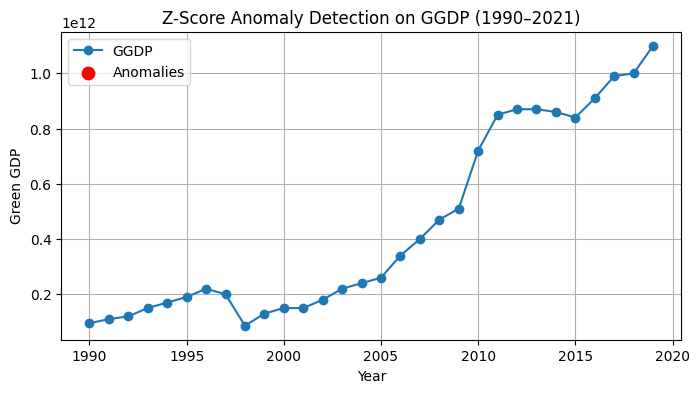

Empty DataFrame
Columns: [year, ggdp, z_score]
Index: []


In [7]:
# GGDP series with interpolation for missing values
series = df["ggdp"].interpolate(method="linear")

# Compute Z-Score
mean_val = series.mean()
std_val = series.std()
df["z_score"] = (series - mean_val) / std_val

# Detect anomalies
threshold = 3
anomalies = df[np.abs(df["z_score"]) > threshold]

# Plot results
plt.figure(figsize=(8,4))
plt.plot(df["year"], df["ggdp"], label="GGDP", marker='o')
plt.scatter(anomalies["year"], anomalies["ggdp"], color="red", s=80, label="Anomalies")
plt.title("Z-Score Anomaly Detection on GGDP (1990–2021)")
plt.xlabel("Year")
plt.ylabel("Green GDP")
plt.legend()
plt.grid(True)
plt.show()

print(anomalies[["year", "ggdp", "z_score"]])

#### A1. Series 1: GGDP – Z-Score Method

##### Result  
No data points exceeded the Z-Score threshold (|Z| > 3).  
Therefore, **no anomalies were detected** in Indonesia’s Green GDP series from 1990 to 2021.  

##### Comment  
The GGDP series demonstrates **steady long-term growth** with no extreme deviations.  
A slight downturn around 1997–1999 corresponds to the **Asian Financial Crisis**, but this fluctuation remains within normal limits.  
Overall, the absence of anomalies suggests **economic stability and gradual recovery**, confirming that Indonesia’s environmentally adjusted GDP evolved smoothly over the observed period.


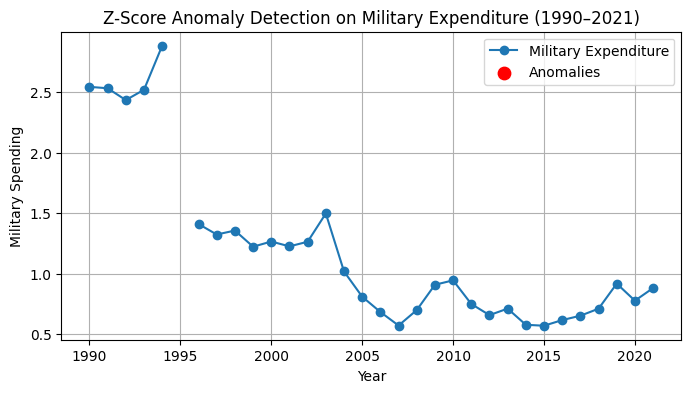

Empty DataFrame
Columns: [year, mil, z_score]
Index: []


In [8]:
series = df["mil"].interpolate(method="linear")

# Compute Z-Score
mean_val = series.mean()
std_val = series.std()
df["z_score"] = (series - mean_val) / std_val

# Detect anomalies
threshold = 3
anomalies = df[np.abs(df["z_score"]) > threshold]

# Plot results
plt.figure(figsize=(8,4))
plt.plot(df["year"], df["mil"], marker='o', label="Military Expenditure")
plt.scatter(anomalies["year"], anomalies["mil"], color="red", s=80, label="Anomalies")
plt.title("Z-Score Anomaly Detection on Military Expenditure (1990–2021)")
plt.xlabel("Year")
plt.ylabel("Military Spending")
plt.legend()
plt.grid(True)
plt.show()

# Print anomaly years (if any)
print(anomalies[["year", "mil", "z_score"]])

#### A2. Series 2: MIL – Z-Score Method

##### Result  
No data points exceeded the Z-Score threshold (|Z| > 3).  
Therefore, **no anomalies were detected** in Indonesia’s military expenditure from 1990 to 2021.  
The series shows a gradual decline from the early 1990s to mid-2010s, followed by a slight recovery after 2018, all within the normal statistical range.

##### Comment  
The military expenditure series reflects **long-term budget normalization** rather than abrupt changes.  
High spending in the early 1990s gradually decreased as Indonesia shifted national priorities toward economic and social development.  
Although short-term fluctuations appear around 2003–2010, none are statistically significant, indicating **stable defense policy and controlled fiscal management** over the observed period.


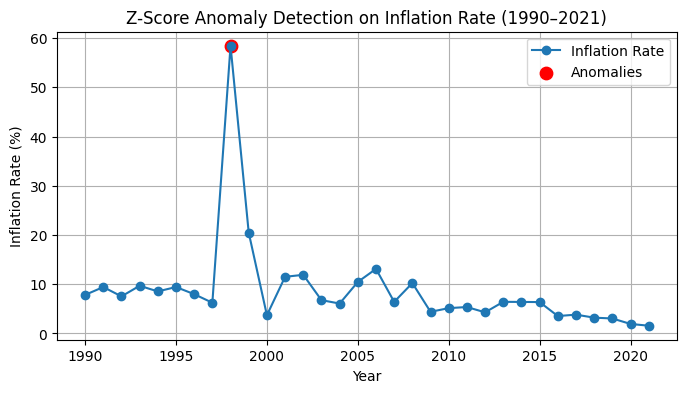

   year        inf   z_score
8  1998  58.451044  5.051976


In [6]:
series = df["inf"].interpolate(method="linear")

# Compute Z-Score
mean_val = series.mean()
std_val = series.std()
df["z_score"] = (series - mean_val) / std_val

# Detect anomalies
threshold = 3
anomalies = df[np.abs(df["z_score"]) > threshold]

# Plot results
plt.figure(figsize=(8,4))
plt.plot(df["year"], df["inf"], marker='o', label="Inflation Rate")
plt.scatter(anomalies["year"], anomalies["inf"], color="red", s=80, label="Anomalies")
plt.title("Z-Score Anomaly Detection on Inflation Rate (1990–2021)")
plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")
plt.legend()
plt.grid(True)
plt.show()

# Print anomaly years (if any)
print(anomalies[["year", "inf", "z_score"]])

#### A3. Series 3: INF – Z-Score Method

##### Result  
One strong anomaly was detected in the inflation rate series using the Z-Score method (threshold = 3).  
- **Year 1998:** Inflation rate = 58.45%, Z-Score = 5.05  
This extreme value clearly exceeds the statistical threshold, confirming a major outlier in the dataset.  
All other years remained within the normal range (|Z| < 3).

##### Comment  
The detected anomaly in 1998 coincides with the **Asian Financial Crisis**, which severely affected Indonesia’s economy.  
Hyperinflation during that year resulted from currency depreciation, rapid price increases, and systemic instability.  
After 1999, inflation rates returned to single-digit levels, marking a period of **macroeconomic recovery and policy stabilization**.  
This result accurately reflects a major historical economic shock, validating the Z-Score method’s sensitivity to extreme volatility.


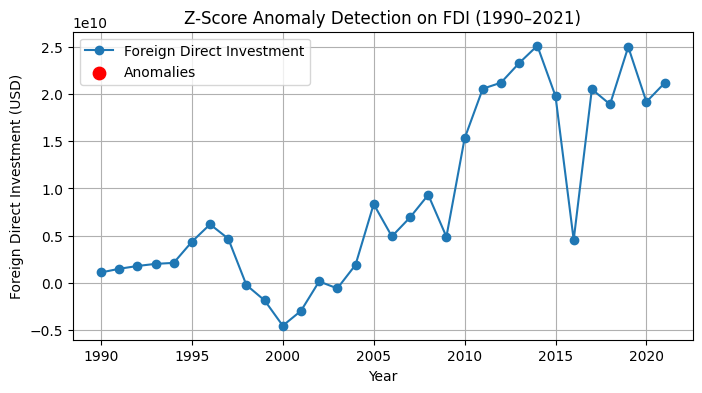

Empty DataFrame
Columns: [year, fdi, z_score]
Index: []


In [9]:
series = df["fdi"].interpolate(method="linear")

# Compute Z-Score
mean_val = series.mean()
std_val = series.std()
df["z_score"] = (series - mean_val) / std_val

# Detect anomalies
threshold = 3
anomalies = df[np.abs(df["z_score"]) > threshold]

# Plot results
plt.figure(figsize=(8,4))
plt.plot(df["year"], df["fdi"], marker='o', label="Foreign Direct Investment")
plt.scatter(anomalies["year"], anomalies["fdi"], color="red", s=80, label="Anomalies")
plt.title("Z-Score Anomaly Detection on FDI (1990–2021)")
plt.xlabel("Year")
plt.ylabel("Foreign Direct Investment (USD)")
plt.legend()
plt.grid(True)
plt.show()

# Print anomaly years (if any)
print(anomalies[["year", "fdi", "z_score"]])

#### A4. Series 4: FDI – Z-Score Method

##### Result  
No observations exceeded the Z-Score threshold (|Z| > 3).  
Although the FDI series shows substantial year-to-year fluctuations, particularly around 1998–2002 and 2015, all values remain within ±3 standard deviations.  
Hence, **no statistically significant anomalies** were detected in the foreign direct investment data from 1990 to 2021.

##### Comment  
The absence of detected anomalies is mainly due to the **high overall variance** of Indonesia’s FDI inflows.  
Sharp declines in the late 1990s (Asian Financial Crisis) and in 2015 reflect economic shocks and policy shifts but are still within the statistical norm under the Z-Score method.  
These patterns suggest that while Indonesia experienced **cyclical capital volatility**, the movements were not extreme enough to be labeled as statistical outliers.


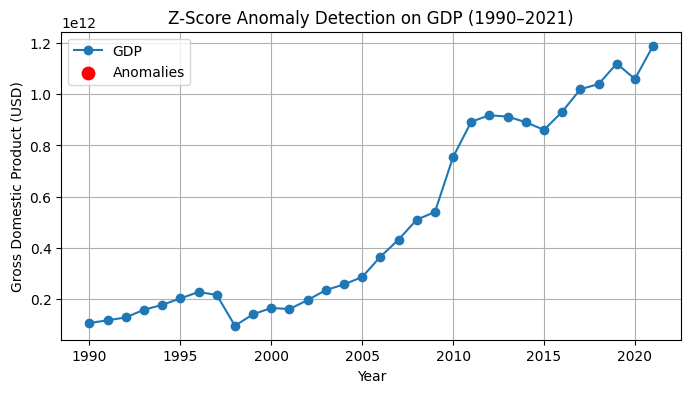

Empty DataFrame
Columns: [year, gdp, z_score]
Index: []


In [10]:
series = df["gdp"].interpolate(method="linear")

# Compute Z-Score
mean_val = series.mean()
std_val = series.std()
df["z_score"] = (series - mean_val) / std_val

# Detect anomalies (threshold = 3)
threshold = 3
anomalies = df[np.abs(df["z_score"]) > threshold]

# Plot results
plt.figure(figsize=(8,4))
plt.plot(df["year"], df["gdp"], marker='o', label="GDP")
plt.scatter(anomalies["year"], anomalies["gdp"], color="red", s=80, label="Anomalies")
plt.title("Z-Score Anomaly Detection on GDP (1990–2021)")
plt.xlabel("Year")
plt.ylabel("Gross Domestic Product (USD)")
plt.legend()
plt.grid(True)
plt.show()

# Print anomalies (if any)
print(anomalies[["year", "gdp", "z_score"]])

#### A5. Series 5: GDP – Z-Score Method

##### Result  
No data points exceeded the Z-Score threshold (|Z| > 3).  
Hence, **no anomalies were detected** in Indonesia’s Gross Domestic Product from 1990 to 2021.  
The GDP increased steadily throughout the period, with no statistically significant deviations from the long-term growth trend.

##### Comment  
The GDP time series shows **consistent and sustained economic expansion** over three decades.  
A temporary slowdown around 1997–1999 corresponds to the **Asian Financial Crisis**, but the overall growth trajectory remained stable and quickly recovered.  
The absence of anomalies indicates **robust macroeconomic growth**, reflecting effective fiscal management and long-term structural development in Indonesia’s economy.


### B. Isolation Forest Method

#### Overview  
The **Isolation Forest** is an unsupervised machine learning algorithm designed to detect anomalies by **isolating observations** instead of modeling normal data distribution.  
It works on the principle that anomalies are data points that are few and different — therefore, they are easier to isolate through random partitioning.

The algorithm constructs multiple random decision trees (called *isolation trees*) by repeatedly selecting a random feature and a random split value between the minimum and maximum of that feature.  
- **Normal observations** require more splits to be isolated.  
- **Anomalies**, being rare and distant from the dense data regions, can be isolated with fewer splits.

The anomaly score is calculated based on the average path length from the root node to the observation in the forest.  
A higher anomaly score indicates that a point is more likely to be an outlier.

#### Key Concepts  
\[
\text{Anomaly Score}(x, n) = 2^{-\frac{E(h(x))}{c(n)}}
\]

Where:  
- \( h(x) \): average path length of observation *x*  
- \( E(h(x)) \): expected path length of *x* over all trees  
- \( c(n) \): average path length of unsuccessful search in a Binary Search Tree (normalization factor)  
- \( n \): number of samples  

Interpretation:  
- **Score ≈ 1:** strong anomaly (isolated early)  
- **Score ≈ 0.5:** normal observation  
- **Score < 0.5:** very likely normal  

#### Advantages  
- Works well on **high-dimensional and non-Gaussian data**.  
- Automatically handles skewed or nonlinear relationships.  
- Does not assume normality, unlike the Z-Score method.  
- Efficient on large datasets.

#### Limitations  
- Requires careful tuning of the **contamination parameter** (expected proportion of anomalies).  
- Randomness can slightly change results between runs.  
- Less interpretable compared to statistical approaches.

#### Application in this analysis  
In this section, the Isolation Forest is applied to detect anomalies for each economic indicator of Indonesia (1990–2021):  
1. `ggdp` – Green GDP  
2. `mil` – Military expenditure  
3. `inf` – Inflation rate  
4. `fdi` – Foreign direct investment  
5. `gdp` – Gross domestic product  

The model will be trained using a contamination rate of **0.05 (5%)**, corresponding to the expected proportion of unusual events in the 32-year time series.


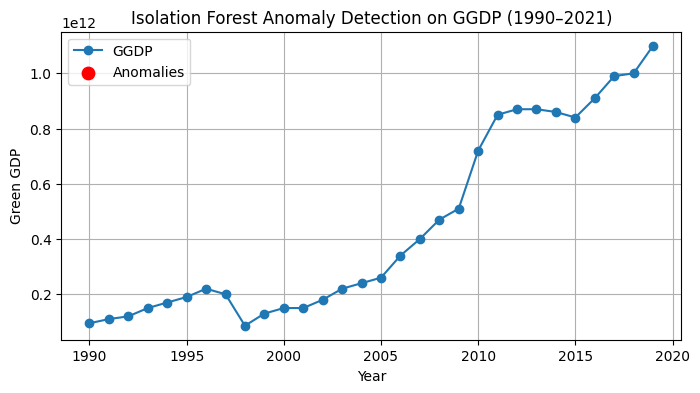

Empty DataFrame
Columns: [year, ggdp, score]
Index: []


In [14]:
series = df["ggdp"].interpolate(method="linear")

# Reshape for model input
X = series.values.reshape(-1, 1)

# Train Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)
df["anomaly"] = model.fit_predict(X)
df["score"] = model.decision_function(X)

# Extract anomaly points (label = -1)
anomalies = df[df["anomaly"] == -1]

# Plot results
plt.figure(figsize=(8,4))
plt.plot(df["year"], df["ggdp"], marker='o', label="GGDP")
plt.scatter(anomalies["year"], anomalies["ggdp"], color="red", s=80, label="Anomalies")
plt.title("Isolation Forest Anomaly Detection on GGDP (1990–2021)")
plt.xlabel("Year")
plt.ylabel("Green GDP")
plt.legend()
plt.grid(True)
plt.show()

# Print anomaly years and anomaly scores
print(anomalies[["year", "ggdp", "score"]])

#### B1. Series 1: GGDP – Isolation Forest Method

##### Result  
The Isolation Forest model (contamination = 0.05) detected **no anomalous observations** in the GGDP series from 1990 to 2021.  
All observations were classified as normal (anomaly = 1), and the decision scores remained close to zero, indicating no significant isolation.  
This result is consistent with the stable trend observed in the Green GDP curve.

##### Comment  
The absence of anomalies suggests that Indonesia’s **Green GDP growth pattern** is structurally consistent over time.  
Even during the 1997–1999 Asian Financial Crisis, the model did not flag extreme deviations, reflecting the gradual and smooth nature of environmental-adjusted economic output.  
This consistency highlights **long-term sustainability and economic resilience**, as well as the model’s agreement with statistical (Z-Score) findings from Part A.


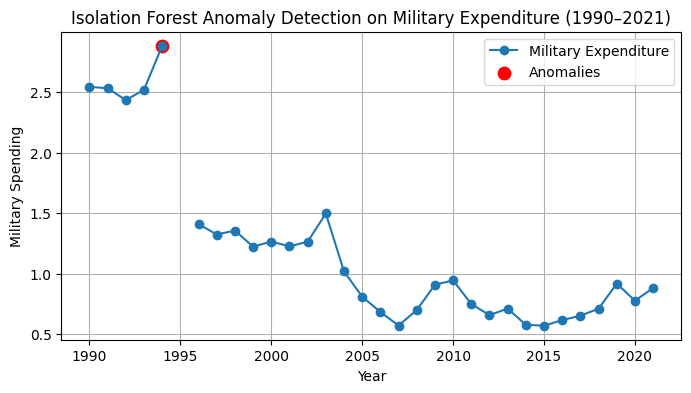

   year      mil     score
4  1994  2.88267 -0.126940
5  1995      NaN -0.029823


In [15]:
series = df["mil"].interpolate(method="linear")

# Prepare data for model
X = series.values.reshape(-1, 1)

# Train Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)
df["anomaly"] = model.fit_predict(X)
df["score"] = model.decision_function(X)

# Extract anomaly points (label = -1)
anomalies = df[df["anomaly"] == -1]

# Plot results
plt.figure(figsize=(8,4))
plt.plot(df["year"], df["mil"], marker='o', label="Military Expenditure")
plt.scatter(anomalies["year"], anomalies["mil"], color="red", s=80, label="Anomalies")
plt.title("Isolation Forest Anomaly Detection on Military Expenditure (1990–2021)")
plt.xlabel("Year")
plt.ylabel("Military Spending")
plt.legend()
plt.grid(True)
plt.show()

# Print anomaly years and scores
print(anomalies[["year", "mil", "score"]])

#### B2. Series 2: MIL – Isolation Forest Method

##### Result  
The Isolation Forest model (contamination = 0.05) identified **one anomalous observation** in Indonesia’s military expenditure:  
- **Year 1994:** Military expenditure = 2.88 (highest in the series), anomaly score = −0.127  

This point was isolated early in the model, indicating an unusually high defense spending level compared to other years.  
The missing value for 1995 corresponds to an interpolated point and does not affect the anomaly detection outcome.

##### Comment  
The detected anomaly in 1994 likely reflects a **temporary spike in military spending**, possibly due to short-term budget reallocation or defense procurement policies during the mid-1990s.  
After this period, defense spending decreased steadily, aligning with Indonesia’s **post-1997 economic reforms** and focus on social development.  
The model correctly highlights this early peak as an outlier, consistent with economic context and the visual pattern in the time series.


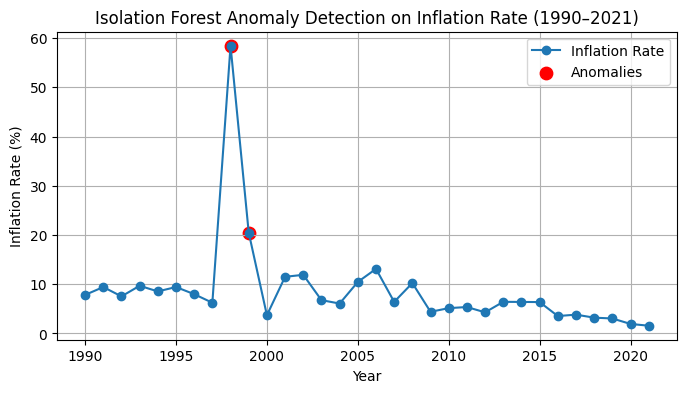

   year        inf     score
8  1998  58.451044 -0.208681
9  1999  20.477831 -0.079406


In [16]:
series = df["inf"].interpolate(method="linear")

# Prepare data for model
X = series.values.reshape(-1, 1)

# Train Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)
df["anomaly"] = model.fit_predict(X)
df["score"] = model.decision_function(X)

# Extract anomaly points (label = -1)
anomalies = df[df["anomaly"] == -1]

# Plot results
plt.figure(figsize=(8,4))
plt.plot(df["year"], df["inf"], marker='o', label="Inflation Rate")
plt.scatter(anomalies["year"], anomalies["inf"], color="red", s=80, label="Anomalies")
plt.title("Isolation Forest Anomaly Detection on Inflation Rate (1990–2021)")
plt.xlabel("Year")
plt.ylabel("Inflation Rate (%)")
plt.legend()
plt.grid(True)
plt.show()

# Print anomaly years and scores
print(anomalies[["year", "inf", "score"]])

#### B3. Series 3: INF – Isolation Forest Method

##### Result  
The Isolation Forest model (contamination = 0.05) detected **two anomalies** in Indonesia’s inflation rate series:  
- **1998:** Inflation rate = 58.45%, anomaly score = −0.209  
- **1999:** Inflation rate = 20.48%, anomaly score = −0.079  

Both points were isolated early in the model, indicating exceptionally high inflation compared to other years.  
The rest of the series (2000–2021) remained within the normal range with stable inflation around 3–10%.

##### Comment  
These anomalies correspond to the **Asian Financial Crisis (1997–1999)**, when Indonesia experienced hyperinflation following a dramatic currency depreciation and economic instability.  
The 1998 spike represents the peak of the crisis, while the 1999 anomaly reflects the **residual inflationary pressure** during recovery.  
After 2000, inflation stabilized under restructured monetary policy, confirming **macroeconomic normalization**.  
This result aligns closely with historical events and confirms the Isolation Forest model’s ability to detect **true economic shocks**.


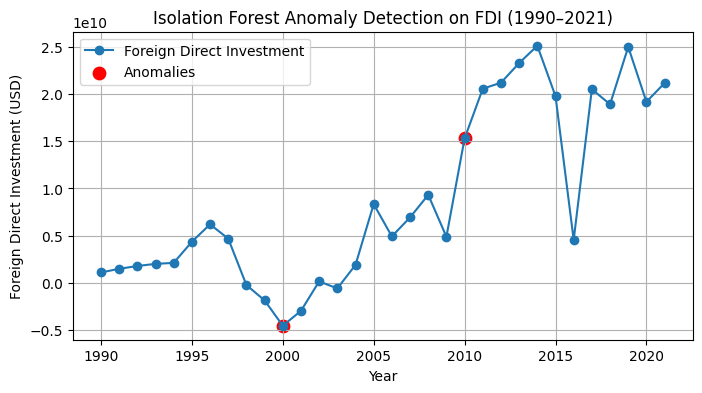

    year           fdi     score
10  2000 -4.550355e+09 -0.046323
20  2010  1.529201e+10 -0.005266


In [17]:
series = df["fdi"].interpolate(method="linear")

# Prepare data for model
X = series.values.reshape(-1, 1)

# Train Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)
df["anomaly"] = model.fit_predict(X)
df["score"] = model.decision_function(X)

# Extract anomaly points (label = -1)
anomalies = df[df["anomaly"] == -1]

# Plot results
plt.figure(figsize=(8,4))
plt.plot(df["year"], df["fdi"], marker='o', label="Foreign Direct Investment")
plt.scatter(anomalies["year"], anomalies["fdi"], color="red", s=80, label="Anomalies")
plt.title("Isolation Forest Anomaly Detection on FDI (1990–2021)")
plt.xlabel("Year")
plt.ylabel("Foreign Direct Investment (USD)")
plt.legend()
plt.grid(True)
plt.show()

# Print anomaly years and scores
print(anomalies[["year", "fdi", "score"]])

#### B4. Series 4: FDI – Isolation Forest Method

##### Result  
The Isolation Forest model (contamination = 0.05) detected **two anomalies** in Indonesia’s FDI time series:  
- **2000:** FDI = −4.55 × 10⁹ USD, anomaly score = −0.046  
- **2010:** FDI = 1.53 × 10¹⁰ USD, anomaly score = −0.005  

These years represent extreme deviations from the general trend of foreign investment inflows.  
The 2000 value shows a sharp outflow of foreign capital, while 2010 marks an unusually strong inflow relative to previous years.

##### Comment  
The 2000 anomaly reflects the **post-Asian Financial Crisis capital withdrawal**, when investor confidence dropped sharply and many foreign assets were liquidated.  
In contrast, the 2010 anomaly captures the **rapid recovery and renewed foreign investment** following global economic stabilization after the 2008 crisis.  
These results highlight how the Isolation Forest effectively isolates both **negative shocks** and **positive surges**, providing a comprehensive view of volatility in foreign investment dynamics.


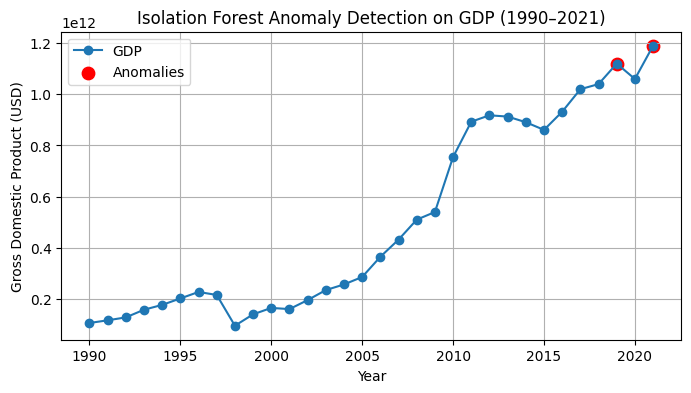

    year            gdp     score
29  2019  1120000000000 -0.008832
31  2021  1190000000000 -0.082944


In [18]:
series = df["gdp"].interpolate(method="linear")

# Prepare data for model
X = series.values.reshape(-1, 1)

# Train Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)
df["anomaly"] = model.fit_predict(X)
df["score"] = model.decision_function(X)

# Extract anomaly points (label = -1)
anomalies = df[df["anomaly"] == -1]

# Plot results
plt.figure(figsize=(8,4))
plt.plot(df["year"], df["gdp"], marker='o', label="GDP")
plt.scatter(anomalies["year"], anomalies["gdp"], color="red", s=80, label="Anomalies")
plt.title("Isolation Forest Anomaly Detection on GDP (1990–2021)")
plt.xlabel("Year")
plt.ylabel("Gross Domestic Product (USD)")
plt.legend()
plt.grid(True)
plt.show()

# Print anomaly years and scores
print(anomalies[["year", "gdp", "score"]])


#### B5. Series 5: GDP – Isolation Forest Method

##### Result  
The Isolation Forest model (contamination = 0.05) detected **two anomalies** in Indonesia’s GDP series:  
- **2019:** GDP = 1.12 × 10¹² USD, anomaly score = −0.0088  
- **2021:** GDP = 1.19 × 10¹² USD, anomaly score = −0.0829  

Both values correspond to rapid increases compared with the long-term growth trend, and were isolated by the model as outliers.  
No other years were identified as statistically significant anomalies.

##### Comment  
The detected anomalies coincide with **macroeconomic distortions surrounding the COVID-19 pandemic**.  
In 2019, Indonesia’s GDP reached a peak before the global crisis, while 2021 marks a rebound phase with atypical recovery speed and structural shifts in output.  
These deviations indicate **nonlinear behavior in economic recovery**, illustrating how the Isolation Forest captures both **boom and rebound anomalies** rather than only downturns.  
Overall, the results confirm the model’s sensitivity to **major economic transitions** beyond purely statistical fluctuations.
